# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Marcelo Palma M.
- Nombre de alumno 2: Isaac Torrejón O.

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/Mpalma325/Laboratorio-de-Programacion-Cientifica-para-Ciencia-de-Datos)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. Los datos de entrenamiento se usan para que el modelo aprenda los patrones, mientras que los de validación se usan para ver si sigue funcionando bien con datos nuevos y evitar sobreajuste (Y, de ser necesario, ajustar hiperparámetros).

2. En aprendizaje no supervisado no tenemos etiquetas que indiquen la clase real de cada observación (a diferencia del supervisado en donde se conoce tanto la entrada como la salida), provocando que no exista una clase "correcta", por lo que no podemos ajustar o enseñar al modelo como lo haríamos en aprendizaje supervisado, y al no existir esta no podemos calcular métricas tradicionales como accuracy, recall, etc... Debiendo recurrir a medidas indirectas, como Silhoutte.

3. La matriz de confusión muestra el número de aciertos y errores del modelo por cada clase, permitiendo observar en cuantos casos el modelo coincide y/o difiere en la asignacion de clases con respecto al valor real.

4. Teniendo en cuenta que;

  - **TP: True positive (Real positivo)**
  - **FT: False Positive (Falso positivo)**
  - **FN: False Negative (Falso negativo)**
  - **TN: True Negative (Real negativo)**
    
      las formulas de las metricas mencionadas son las siguientes:

  - **Accuracy. Mide la proporcion de predicciones correctas con respecto al total**

  $$ \frac{TP + TN}{TP+FP+FN+TN}$$


  - **Precision. Mide la proporcion de reales positivos con respecto a todas las veces que el modelo clasificó como positivos**

  $$\frac{\text{TP}}{\text{TP} + \text{FP}}$$


  - **Recall. Mide la proporcion de los TP que el modelo clasificó con respecto a todos los positivos del dataset, apuntando a minimizar los FN**

  $$\dfrac{TP}{TP + FN}$$

  - **F1-score. Mide qué tan bien el modelo logra el equilibrio entre precisión y recall, castigando mucho cuando una métrica es muy baja**

  $$2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

5. Considera que, en general, si se busca evitar FP se prioriza precision, y si se busca evitar FN se usa recall, los casos nos quedarian de la siguiente forma:

 - **Mantenimiento predictivo de maquinaria pesada:** Recall (importa no dejar fallas sin detectar).

 - **Detección de enfermedades altamente contagiosas:** Recall (es prioridad detectar todos los casos positivos posible y evitar FN).

 - **Aprobación de créditos de alto riesgo:** Precision (es importante no aprobar créditos a personas riesgosas).

 - **Detección de crímenes:** Recall (prioridad en detectar todos los crímenes posibles y en no dejar pasar delitos graves sin detectar).

 6. La calibración de un modelo es el proceso de ajustar las probabilidades que entrega un clasificador para que reflejen fielmente la frecuencia real de ocurrencia de la clase positiva. Un modelo perfectamente calibrado, de todas las instancias a las que se les asigna una probabilidades p, aprox. el p% resulta ser realmente positivas, permitiendo calcular valores esperados de forma confiable o calcular niveles de certidumbre.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [1]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# carga de dataframe:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Lab5/stats_players.csv')
df.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

#### 1.1.1

In [3]:
dfLabel = df.copy()
dfLabel['label'] = dfLabel['National_Position'].apply(lambda x: 0 if pd.isna(x) else 1)

#### 1.1.2

In [4]:
dfLabel['label'].value_counts()

,count
label,
0,16513
1,1075


A partir de los resultados obtenidos, podemos notar que la mayoria de los jugadores del dataset no son seleccionados nacionales (Siendo bastante aterrizado a la realidad ya que son 23-26 jugadores seleccionados para representar a su pais en competencias internacionales)

#### 1.1.3

In [5]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

categorical_features = ['Club_Position', 'Preffered_Foot', 'Work_Rate', 'Nationality']
numerical_features = df.select_dtypes(include='int64').columns.tolist()

numerical_pipeline = Pipeline([
    ('scaler', MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Llena categorías faltantes
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # Convierte a valores numéricos
])

# ColumnTransformer
col_transformer = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

#### 1.1.4

*   **Variables categóricas:** Se aplica imputer simple para evitar casos faltantes (es solo un caso según reporte, en Club_Position, ya que en el caso de National_Position coincide que los 1075 seleccionados tienen posiciones) y one-hot encoding para convertir a datos númericos que el modelo pueda entender.

*  **Variables numéricas:** A pesar de que los datos tienen un comportamiento con "tendencias" normal, no poseen valores nulos y no hay outliers extremos, se aplica un MinMax scaler, con el fin de evitar distintas escalas en variables como age, height y las habilidades.

*  **Variables no consideradas:** No se considerara la variable Name en las transformaciones, ya que no aportaria mucha información al modelo y aumentaría drásticamente la dimensionalidad de este, ni National_Position, ya que label es construida a partir de esta, generando una alta correlación y pudiendo provocar que el modelo solo considere esta variable.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

#### 1.2.1

In [6]:
from sklearn.model_selection import train_test_split

X = dfLabel.drop(columns=['National_Position', 'Name', 'label']) # eliminar variables que no son de interés y la etiqueta
y = dfLabel['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7202, stratify=y) # stratify para evitar desbalance

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining set label distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting set label distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (14070, 37)
Testing set shape: (3518, 37)

Training set label distribution:
 label
0    0.938877
1    0.061123
Name: proportion, dtype: float64

Testing set label distribution:
 label
0    0.938886
1    0.061114
Name: proportion, dtype: float64


#### 1.2.2

In [7]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# parametros para evitar efectos de desbalance
n_positive = y_train.sum()
n_negative = len(y_train) - n_positive

pipeline_xgboost = Pipeline([
    ('preprocessor', col_transformer),
    ('classifier', XGBClassifier(
        scale_pos_weight=(n_negative / n_positive),
        max_depth=8,
        alpha=1.5,
        random_state=7202
    ))
])

pipeline_lightgbm = Pipeline([
    ('preprocessor', col_transformer),
    ('classifier', LGBMClassifier(
        is_unbalance=True,
        max_depth=8,
        reg_alpha=1.5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=7202
    ))
])


#### 1.2.3

In [8]:
xgboost = pipeline_xgboost.fit(X_train, y_train)
lightgbm = pipeline_lightgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2656
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

#### 1.3.1

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

def calcular_metricas(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return accuracy, precision, recall

y_pred_xgboost = xgboost.predict(X_test)
y_pred_lightgbm = lightgbm.predict(X_test)

# XGBoost
print("XGBoost:")
acc_xgb, prec_xgb, rec_xgb = calcular_metricas(y_test, y_pred_xgboost)
print(f"Accuracy: {acc_xgb:.4f}")
print(f"Precision (clase positiva): {prec_xgb:.4f}")
print(f"Recall (clase positiva): {rec_xgb:.4f}")
print(classification_report(y_test, y_pred_xgboost))

# LightGBM
print("\nLightGBM:")
acc_lgb, prec_lgb, rec_lgb = calcular_metricas(y_test, y_pred_lightgbm)
print(f"Accuracy: {acc_lgb:.4f}")
print(f"Precision (clase positiva): {prec_lgb:.4f}")
print(f"Recall (clase positiva): {rec_lgb:.4f}")
print(classification_report(y_test, y_pred_lightgbm))

XGBoost:
Accuracy: 0.9375
Precision (clase positiva): 0.4903
Recall (clase positiva): 0.5907
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3303
           1       0.49      0.59      0.54       215

    accuracy                           0.94      3518
   macro avg       0.73      0.78      0.75      3518
weighted avg       0.94      0.94      0.94      3518


LightGBM:
Accuracy: 0.9079
Precision (clase positiva): 0.3786
Recall (clase positiva): 0.7907
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      3303
           1       0.38      0.79      0.51       215

    accuracy                           0.91      3518
   macro avg       0.68      0.85      0.73      3518
weighted avg       0.95      0.91      0.92      3518



#### 1.3.2

El valor de Accuracy indica, tanto para seleccionados como no seleccionados, la proporción de jugadores que fueron correctamente clasificados.

Luego, Precision indica qué proporción de los jugadores que el modelo clasifica como seleccionados efectivamente lo son.

Seguido, Recall, de la clase positiva, indica el porcentaje del total de jugadores seleccionados que el modelo efectivamente los clasificó como seleccionados.

Finalmente, el desbalance notorio entre clases afecta de manera negativa el desempeño general del modelo al momento de clasificar, impidiendo alcanzar métricas elevadas, o bien resultados optimos. Si el modelo se centra únicamente en maximizar el Accuracy, puede caer en la estrategia de predecir siempre la clase mayoritaria, lo que genera un sesgo que reduce Precision y Recall. (clase minoritaria es "menos reconocida" por el modelo, limitando su capacidad de identificar correctamente a los jugadores seleccionados.)

#### 1.3.3

La métrica más adecuada para comparar es el f1-score de la clase positiva, ya que considera tanto precision como recall en los casos de mayor dificultad para el modelo (clase minoritaria), siendo a su vez el modelo de XGBoost el que alcanza un valor, levemente, superior (0.54) haciendolo el mejor modelo a elegir.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

#### 2.1

In [10]:
position_map = {
    **dict.fromkeys(['GK'], 'arquero'),
    **dict.fromkeys(['RB', 'CB', 'LB'], 'defensa'),
    **dict.fromkeys(['RWB', 'CDM', 'LWB'], 'central_defensa'),
    **dict.fromkeys(['RM', 'CM', 'LM'], 'central'),
    **dict.fromkeys(['RW', 'CAM', 'LW'], 'central_ataque'),
    **dict.fromkeys(['ST', 'CF'], 'ataque')
}

df_positions = df.copy()
df_positions['label'] = df_positions['Club_Position'].map(position_map).fillna('Otro')
df_positions = df_positions[df_positions['label'] != 'Otro']

#### 2.2

In [11]:
df_positions['label'].value_counts()

,count
label,
defensa,1180
central,907
arquero,632
central_ataque,581
ataque,430
central_defensa,209


#### 2.3

In [12]:
X2 = df_positions.drop(columns=['Club_Position', 'National_Position', 'Name', 'label'])
y2 = df_positions['label']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=7202, stratify=y2)

In [13]:
numerical_features_pos = X2.select_dtypes(include='number').columns.tolist()
categorical_features_pos = ['Preffered_Foot', 'Work_Rate', 'Nationality']

numerical_pipeline_pos = Pipeline([
    ('scaler', MinMaxScaler())
])

categorical_pipeline_pos = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

col_transformer_pos = ColumnTransformer([
    ('num', numerical_pipeline_pos, numerical_features_pos),
    ('cat', categorical_pipeline_pos, categorical_features_pos)
])


pipeline_xgboost_pos = Pipeline([
    ('preprocessor', col_transformer_pos),
    ('classifier', XGBClassifier(
        max_depth=8,
        alpha=1.5,
        random_state=7202
    ))
])

pipeline_lightgbm_pos = Pipeline([
    ('preprocessor', col_transformer_pos),
    ('classifier', LGBMClassifier(
        max_depth=8,
        reg_alpha=1.5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=7202
    ))
])


In [14]:
label_to_int = {'arquero': 0, 'defensa': 1, 'central_defensa': 2, 'central': 3, 'central_ataque': 4, 'ataque': 5 }

xgboost2 = pipeline_xgboost_pos.fit(X_train2, y_train2.map(label_to_int))
lightgbm2 = pipeline_lightgbm_pos.fit(X_train2, y_train2)

y_pred_xgboost2 = pipeline_xgboost_pos.predict(X_test2)
y_pred_lightgbm2 = pipeline_lightgbm_pos.predict(X_test2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2397
[LightGBM] [Info] Number of data points in the train set: 3151, number of used features: 78
[LightGBM] [Info] Start training from score -1.828938
[LightGBM] [Info] Start training from score -2.214833
[LightGBM] [Info] Start training from score -1.469303
[LightGBM] [Info] Start training from score -1.913438
[LightGBM] [Info] Start training from score -2.937481
[LightGBM] [Info] Start training from score -1.205349
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [15]:
# XGBoost
print("XGBoost:")
print(classification_report(y_test2.map(label_to_int), y_pred_xgboost2))

# LightGBM
print("\nLightGBM:")
print(classification_report(y_test2, y_pred_lightgbm2))

XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       126
           1       0.83      0.94      0.88       236
           2       0.45      0.21      0.29        42
           3       0.58      0.63      0.60       182
           4       0.52      0.39      0.44       116
           5       0.80      0.85      0.82        86

    accuracy                           0.75       788
   macro avg       0.70      0.67      0.67       788
weighted avg       0.73      0.75      0.73       788


LightGBM:
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.82      0.84      0.83        86
        central       0.57      0.65      0.61       182
 central_ataque       0.53      0.39      0.45       116
central_defensa       0.47      0.17      0.25        42
        defensa       0.82      0.92      0.87       236

       accuracy                     

#### 2.4

A partir de los resultados obtenidos, se evidencia que tanto XGBoost como LightGBM poseen desempeños muy similares, clasificando correctamente el 75% de los casos, segun el valor de Accuracy obtenido. En general, ambos obtuvieron buenos resultados con respecto a los valores de Precision y Recall, destacando en las categorias arquero, ataque y defensa, y un desempeño regular en central. Sin embargo, en ambos casos, se observan dificultades en la clasificacion para la categoria central defensa.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 3.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

#### 3.1.1

In [16]:
!pip install pycaret[full]

In [17]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí

dfLabel.drop(columns=['National_Position', 'Name'], inplace=True)

exp = setup(
    data=dfLabel,
    target="label",
    train_size=0.8,
    session_id=7202,
    normalize=False,
    verbose=False,
)

tree_models = ['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
best = compare_models(include=tree_models, sort='Precision', n_select=1)

print("Mejor modelo según precision (menos FP):", best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9473,0.9450,0.2384,0.7021,0.3534,0.3332,0.3878,2.5270
et,Extra Trees Classifier,0.9429,0.9408,0.1186,0.6919,0.2009,0.1867,0.2687,2.3970
catboost,CatBoost Classifier,0.9517,0.9606,0.4151,0.6699,0.5102,0.4864,0.5030,11.1640
xgboost,Extreme Gradient Boosting,0.9512,0.9613,0.4477,0.6453,0.5272,0.5024,0.5125,0.5480
lightgbm,Light Gradient Boosting Machine,0.9510,0.9611,0.4477,0.6441,0.5260,0.5012,0.5115,1.7980
dt,Decision Tree Classifier,0.9288,0.6995,0.4384,0.4193,0.4272,0.3894,0.3902,0.3360


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

Mejor modelo según precision (menos FP): RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=7202, verbose=0,
                       warm_start=False)


A partir de los resultados obtenidos, se observa que Random Forest Classifier presenta la mayor Precision, con un valor de 0.7021. Ahora, considerando la definicion de Precision, tenemos la proporcion de reales positivos con respecto a todas las veces que el modelo clasificó como positivos es de un 70% (el 30% de todos los jugadores que clasifica como seleccionados son FP). Con respecto a las otras metricas, se puede decir que es un algoritmo rapido, demorandose 2.1990 seg, y presenta un Recall moderado-bajo, lo cual en este caso no es tan relevante ya que se busca minimizar los FP, siendo el modelo mas adecuado para la tarea en cuestion.

#### 3.1.2

- **Extra Trees Classifier. et**

  Conjunto de árboles que llevan la aleatoriedad un paso más allá. Se entrenan sobre el dataset completo (sin bootstrap) y para cada nodo se seleccionan al azar tanto la característica como el umbral de corte (no se buscan métricas de impureza para elegir el mejor split), siendo muy rápidos de entrenar y algo más sesgados, pero con baja varianza y robustos al ruido.

- **Random Forest Classifier. rf**

  Conjunto de N árboles de decisión entrenados sobre bootstrap samples (muestras aleatorias con reemplazo) del dataset. En cada división, en lugar de probar todas las variables, solo considera un subconjunto aleatorio de ellas. Luego promedia (regresión) o vota (clasificación) las predicciones de todos los árboles, reduciendo drásticamente la varianza y el sobreajuste del árbol único.

- **Decision Tree Classifier. dt**

  Modelo que particiona recursivamente el espacio de características mediante preguntas del tipo “¿feature X ≤ t?” para separar lo más puramente posible las clases. Es muy rápido en inferencia y fácil de interpretar, pero en profundidad alta tiende a sobreajustarse.

#### 3.1.3

In [18]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

- **Confusión Matrix**

  A partir de la matriz, se observa que 3281 de 3442 son TN (95% de los casos negativos fueron bien clasificados) y 54 de 76 son TP (71% de los casos positivos fueron bien clasificados), presentando mayor dificultad para clasificar la clase positiva

- **Threshold**

  A partir del gráfico, se observa que el threshold por defecto (0.25) está muy cercano al punto que maximiza f1, sin embargo, como nuestro objetivo es la precision, puede no ser el umbral ideal.

- **Feature Importance**

  Notamos que la variable con mayor importancia es nationality, esto puede estar causado por la cantidad de jugadores por pais y la popularidad del futbol en este mismo, ya que tendre "mas/menos" candidatos de jugadores que puedo seleccionar para que representen al pais (Ejemplo: Inglaterra es un pais donde el futbol es muy popular, teniendo varios jugadores en activo (tanto en ligas nacionales como extranjeras) por lo cual se hace "mas dificil" elegir a los que representaran al pais. Luego, siguen las variables relacionadas a las habilidades y caracteristicas de los jugadores, tales como Reactions, Ball_Control, Standing_Tackle o Composure, siendo un indicador de las caracteristicas mas importantes a la hora de seleccionar jugadores (Notar que las mencionadas son levemente superior al resto habilidades y caracteristicas de los jugadores).


- **Learning Curve**

  La curva muestra un buen resultado, en donde el score de validación aumenta progresivamente con el número de instancias, llegando a valores cercanos a 0.95.

### 3.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

#### 3.2.1

In [20]:
df = pd.read_csv('/content/drive/MyDrive/Lab5/stats_players.csv')
df["label"] = df["National_Position"].notna().astype(int)

X = df.drop(columns=["National_Position","Name","label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7202, stratify=y
)

# Preprocesamiento
num_feats = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_feats = ["Club_Position","Preffered_Foot","Work_Rate","Nationality"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

ct = ColumnTransformer([
    ("num", num_pipe, num_feats),
    ("cat", cat_pipe, cat_feats),
])

X_tr = ct.fit_transform(X_train)
X_ts = ct.transform(X_test)
feature_names = ct.get_feature_names_out()

# Entrenar XGBoost con todas las features
model_full = XGBClassifier(use_label_encoder=False,
                           eval_metric="logloss",
                           random_state=7202)
model_full.fit(X_tr, y_train)
y_pred_full = model_full.predict(X_ts)
metrics_full = {
    "f1": f1_score(y_test, y_pred_full),
    "precision": precision_score(y_test, y_pred_full),
    "recall": recall_score(y_test, y_pred_full),
    "accuracy": accuracy_score(y_test, y_pred_full),
}

#### 3.2.2

In [36]:
# Importancia de features

imp = model_full.get_booster().get_score(importance_type="gain")
imp_df = pd.DataFrame({
    "feature": list(imp.keys()),
    "gain": list(imp.values())
}).sort_values("gain", ascending=False).reset_index(drop=True)

#### 3.2.3

In [22]:
# Recursiva para eliminar Features

results = []
for k in range(5, len(feature_names)+1, 5):
    top_feats = imp_df["feature"].iloc[:k].values
    idx = [int(f[1:]) for f in top_feats]
    Xk_tr = X_tr[:, idx]
    Xk_ts = X_ts[:, idx]
    m = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=7202
    )
    m.fit(Xk_tr, y_train)
    preds_k = m.predict(Xk_ts)
    results.append({'n_features': k, 'f1': f1_score(y_test, preds_k)})

res_df = pd.DataFrame(results)

#### 3.2.4

In [23]:
threshold = metrics_full["f1"] * 0.98
candidates = res_df[res_df["f1"] >= threshold]
N = int(candidates.iloc[0]["n_features"]) if not candidates.empty else len(feature_names)


topN = imp_df["feature"].iloc[:N].values
idxN = [int(f[1:]) for f in topN]

model_red = XGBClassifier(use_label_encoder=False,
                          eval_metric="logloss",
                          random_state=7202)
model_red.fit(X_tr[:, idxN], y_train)
y_pred_red = model_red.predict(X_ts[:, idxN])

metrics_red = {
    "f1": f1_score(y_test, y_pred_red),
    "precision": precision_score(y_test, y_pred_red),
    "recall": recall_score(y_test, y_pred_red),
    "accuracy": accuracy_score(y_test, y_pred_red),
}

print("Métricas modelo completo \n", metrics_full)
print("Métricas modelo reducido \n", metrics_red)
print(f"Se quedaron N={N} features de {len(feature_names)} originales.")

Métricas modelo completo 
 {'f1': 0.4899135446685879, 'precision': 0.6439393939393939, 'recall': 0.3953488372093023, 'accuracy': 0.94968732234224}
Métricas modelo reducido 
 {'f1': 0.5254237288135594, 'precision': 0.6690647482014388, 'recall': 0.4325581395348837, 'accuracy': 0.9522455940875497}
Se quedaron N=45 features de 226 originales.


####3.2.5

- El rendimiento del modelo con las características seleccionadas, pasando de 226 a 45 variables, mejor levemente en las metricas en estudio. F1 paso de 0.489 a 0.525, Precision de 0.643 a 0.669, Recall de 0.395 a 0.432 y Accuracy de 0.949 a 0.9522. A partir de la reduccion de variables, el modelo aumenta ligeramente su poder predictivo, provocando que tambien aumente la precisión y la robustez con respecto al modelo original.

-  los beneficios potenciales de eliminar variables del modelo son:

    - Mayor simplicidad. (Menos features resultan en arboles y pipelines más cortos)

    - Mayor Velocidad. (Se reduce el tiempo de ejecucion debido a que cada split evalúa un menor numero de columnas)

    - Mejor Generalización. (Al quitar variables correlacionadas/ruidosas, se disminuye/mitiga el sobreajuste)

    - Mejora el rendimiento y los resultados del modelo. (Como se observo, el eliminar las variables nos entrego un modelo levemente mejor y "menos pesado")


- El nuevo modelo es más sencillo de explicar ya que al acotar unicamente a 45 variables, ya que de cierta forma la construccion e interpretacion del arbol "mejora" (se vuelve mas simple) sin perder el poder predictivo ni la calidad de los resultados. De igual forma, se puede decir que llega a resultados "mas puros" ya que al quitar variables redundantes/ruidosas mejora las divisiones del árbol, reduce espurias dentro de los resultados, permite mayor entendimiento de causales y, al mejor su generalizacion, sus resultados "son más replicables".

### 3.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

In [24]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

**Respuesta**

####3.3.1

In [25]:
probs_uncalibrated = model_red.predict_proba(X_ts[:, idxN])[:, 1]
brier_uncalibrated = brier_score_loss(y_test, y_pred_red)
print(f"Brier Score sin calibrar: {brier_uncalibrated:.4f}")

Brier Score sin calibrar: 0.0478


In [26]:
calibrated_model = CalibratedClassifierCV(model_red, method='isotonic', cv=5)
calibrated_model.fit(X_tr[:, idxN], y_train)

CalibratedClassifierCV(cv=5, ensemble=True,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=None, n_jobs=None,
                                               num_parallel_tree=None,
                                               objective='binary:logistic', ...),
                       method='isotonic', n_jobs=None)

In [27]:
probs_calibrated = calibrated_model.predict_proba(X_ts[:, idxN])[:, 1]
brier_calibrated = brier_score_loss(y_test, probs_calibrated)
print(f"Brier Score calibrado: {brier_calibrated:.4f}")

Brier Score calibrado: 0.0369


####3.3.2

A partir de los resultados obtenidos, Se observa que el Brier Score pasa de 0.0478 a 0.0369, indicando que al calibrar se ha reducido la diferencia cuadritica promedio de las probabilidades predichas y las reales. (es decir el modelo calibrado mejoró con respecto al sin calibrar en esta metrica y en rendimiento)

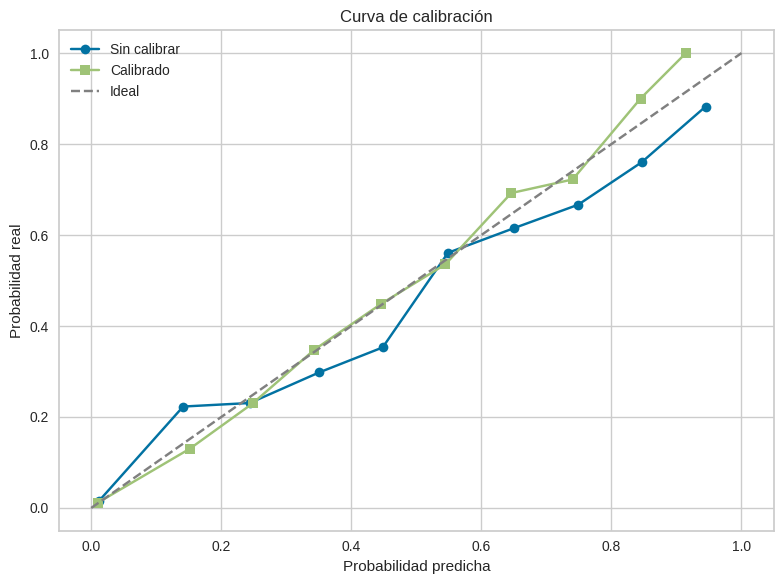

In [28]:
import matplotlib.pyplot as plt

def plot_calibration(y_true, probs1, probs2, name1='Sin calibrar', name2='Calibrado'):
    plt.figure(figsize=(8, 6))

    prob_true1, prob_pred1 = calibration_curve(y_true, probs1, n_bins=10)
    prob_true2, prob_pred2 = calibration_curve(y_true, probs2, n_bins=10)

    plt.plot(prob_pred1, prob_true1, marker='o', label=name1)
    plt.plot(prob_pred2, prob_true2, marker='s', label=name2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')

    plt.xlabel('Probabilidad predicha')
    plt.ylabel('Probabilidad real')
    plt.title('Curva de calibración')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_calibration(y_test, probs_uncalibrated, probs_calibrated)

Finalmente, a partir de la gráfica se observa que  las probabilidades calibradas se acercan más a la referencia ideal en comparacion a las sin calibrar, mejorando la confiabilidad de las probabilidades predichas y haciéndolas más interpretables, lo cual confirma que el modelo calibrado representa mejor la incertidumbre real y exprese su grado de certeza de manera más realista.

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>